In [6]:
import os 
import pandas as pd

file_path = "/media/jrjoseph/Elements/projects/fem_memristor/benchmarking/"

file_name1 = "Geom Scalable I ParametricF.txt"
file_name2 = "Geom Scalable V ParametricF.txt"

file1 = os.path.join(file_path, file_name1)
file2 = os.path.join(file_path, file_name2)

In [7]:
def read_comsol_table(filepath):
    """
    Read a COMSOL exported table into a pandas DataFrame.

    Parameters
    ----------
    filepath : str
        Path to the COMSOL text export.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the numerical table.
    """
    return pd.read_csv(
        filepath,
        comment="%",
        sep=r"\s+",
        header=None,
    )

In [8]:
I_data = read_comsol_table(file1)
V_data = read_comsol_table(file2)

print(I_data.head())
print(V_data.head())

        0    1         2
0  0.0005    0  0.000039
1  0.0005   50  0.505078
2  0.0005  100  1.018214
3  0.0005  150  1.549194
4  0.0005  200  2.105201
        0    1    2
0  0.0005    0  0.0
1  0.0005   50  0.1
2  0.0005  100  0.2
3  0.0005  150  0.3
4  0.0005  200  0.4


In [9]:
import matplotlib.pyplot as plt
import numpy as np


def plot_IV_curves_parametric(I_data, V_data):
    # Unique E_barrier values
    E_barriers = I_data.iloc[:, 0].unique()
    n_plots = len(E_barriers)

    # Choose number of columns
    n_cols = 3
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False
    )

    axes = axes.flatten()

    for i, E_barrier in enumerate(E_barriers):
        ax = axes[i]

        # Select this parameter value
        I_mask = I_data.iloc[:, 0] == E_barrier
        V_mask = V_data.iloc[:, 0] == E_barrier

        # Current and voltage
        current = I_data.loc[I_mask, 2]
        voltage = V_data.loc[V_mask, 2]

        ax.plot(voltage, current)

        ax.set_title(f"$E_{{barrier}}$ = {E_barrier:g}")
        ax.set_xlabel("Voltage (V)")
        ax.set_ylabel("Ionic Current (A)")
        ax.grid(True)

    # Remove unused subplots
    for i in range(n_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

def plot_IV_curves_parametric2(I_data, V_data, parameter_name="E_barrier"):
    # Unique parameter values
    parameters = I_data.iloc[:, 0].unique()

    fig, ax = plt.subplots(figsize=(7, 4.5))

    for parameter in parameters:
        # Select this parameter value
        I_mask = I_data.iloc[:, 0] == parameter
        V_mask = V_data.iloc[:, 0] == parameter

        # Current and voltage
        current = I_data.loc[I_mask, 2]
        voltage = V_data.loc[V_mask, 2]

        ax.plot(
            voltage,
            current,
            label=f"${parameter_name}$ = {parameter:g}"
        )

    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("Ionic Current (A)")
    ax.grid(True)

    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

def plot_IV_curves(I_data, V_data):
    fig, ax = plt.subplots()

    voltage = V_data.iloc[:, 1]
    current = I_data.iloc[:, 1]

    ax.plot(voltage, current)

    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("Ionic Current (A)")
    
    plt.show()

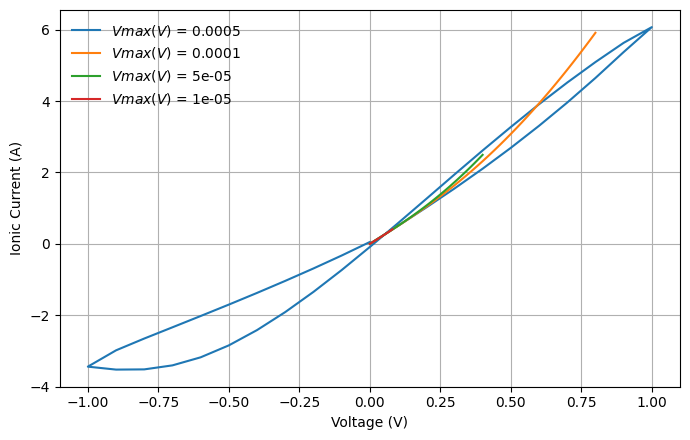

In [10]:
plot_IV_curves_parametric2(I_data, V_data, "Vmax (V)")